# Employee Attrition Prediction Using Machine Learning

### An end-to-end classification project using the IBM HR Analytics Employee Attrition dataset

**Portfolio Project | Python | Scikit-learn | TensorFlow/Keras**

## Executive Summary

Employee attrition creates recruitment, training and productivity challenges for organisations. This project develops and evaluates machine learning models to predict whether an employee is likely to leave, using demographic, job-related, compensation and workplace factors from the IBM HR Analytics Employee Attrition and Performance dataset.

Six classification approaches were evaluated: Logistic Regression, Decision Tree, Random Forest, Naïve Bayes, Gradient Boosting and a Neural Network. The models were compared using accuracy, precision, recall, F1-score and ROC-AUC. Logistic Regression achieved the strongest overall balance of classification performance (87.33% accuracy and 85.51% F1-score), while Random Forest produced the highest ROC-AUC (0.827).

The analysis also identified Monthly Income, Age, Total Working Years, OverTime and Years At Company among the most influential features in the Random Forest model. The project demonstrates a complete machine-learning workflow from data preparation and exploratory analysis through model training, tuning, evaluation and interpretation.

## 1. Business Problem and Objective

Employee attrition can disrupt business continuity, create skills and training gaps, increase recruitment costs and reduce productivity. Predicting which employees may be at higher risk of leaving can support more proactive, data-informed retention strategies.

### Objective

The objective is to develop and compare classification models that predict employee attrition from demographic, job-related and workplace characteristics. The project also evaluates the trade-offs between predictive performance, discrimination ability and model interpretability.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from scikeras.wrappers import KerasClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, Flatten

## 2. Dataset Selection and Exploration

This project uses the **IBM HR Analytics Employee Attrition and Performance** dataset. The dataset contains **1,470 employee records and 35 variables** covering demographics, employment history, compensation, job characteristics and workplace factors.

The target variable is **Attrition**, with two classes: `Yes` (employee left) and `No` (employee stayed).

**Dataset source:** Kaggle — IBM HR Analytics Employee Attrition dataset.

In [3]:
# Step 1: Loading the csv file into datafrrame
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### 2.1 Initial Data Quality Assessment

The dataset was inspected for dimensions, data types, missing values, duplicate records and constant variables. The analysis found no missing values and no duplicated records. Several constant or identifier fields were removed because they do not provide useful predictive information.

In [4]:
# step 2: checking the size, and structure of the dataset as well as checking for missing number
df.shape
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

<bound method DataFrame.sum of         Age  Attrition  BusinessTravel  DailyRate  Department  \
0     False      False           False      False       False   
1     False      False           False      False       False   
2     False      False           False      False       False   
3     False      False           False      False       False   
4     False      False           False      False       False   
...     ...        ...             ...        ...         ...   
1465  False      False           False      False       False   
1466  False      False           False      False       False   
1467  False      False           False      False       False   
1468  False      False           False      False       False   
1469  False      False           False      False       False   

      DistanceFromHome  Education  EducationField  EmployeeCount  \
0                False      False           False          False   
1                False      False           False   

In [5]:
# checking for duplicated values
df.duplicated().sum()

np.int64(0)

In [6]:
# checking the data types
df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [7]:
#checking for constant value
df["Gender"].unique()


<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [8]:
# checking the summary statistics of of the numerical variables of the dataset
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
# check foy unique coloumns and constant column
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [11]:
#checking the values of the constant column. They are identify before removal
df["Over18"]
df["EmployeeCount"]
df["StandardHours"]


0       80
1       80
2       80
3       80
4       80
        ..
1465    80
1466    80
1467    80
1468    80
1469    80
Name: StandardHours, Length: 1470, dtype: int64

### 2.2 Removing Non-Informative Variables

Variables with a single unique value cannot help distinguish employees who leave from those who stay. Constant fields and the employee identifier were therefore removed before modelling.

In [12]:
#dropping constant column that can add nothing to the model
df.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"], inplace=True)

In [13]:
#checking the distribution of target variable.
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

### 2.3 Target Class Distribution

The target is moderately imbalanced: approximately **84% of employees stayed** while **16% left**. Because accuracy alone can hide poor performance on the minority class, precision, recall, F1-score and ROC-AUC are also used throughout model evaluation.

In [14]:
# Separating Features and Target Variable
X= df.drop("Attrition", axis=1)
y = df["Attrition"]

<Axes: xlabel='MonthlyIncome'>

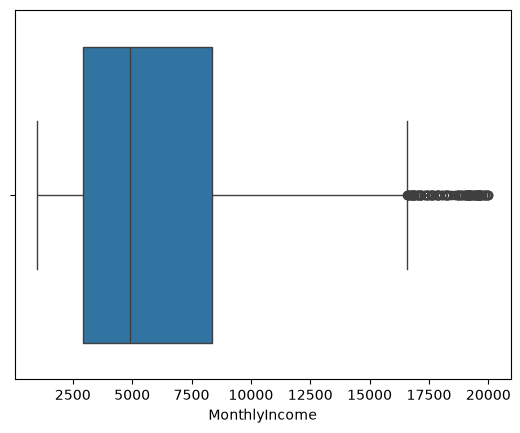

In [15]:
#Checking for outlier in only monthly income 
import seaborn as sns
sns.boxplot(x=df["MonthlyIncome"])

In [16]:
#Checking the values of the outlier to determine if they are to be retained or removed
df[df["MonthlyIncome"]> 17000]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
25,53,No,Travel_Rarely,1282,Research & Development,5,3,Other,3,Female,...,3,4,1,26,3,2,14,13,4,8
29,46,No,Travel_Rarely,705,Sales,2,4,Marketing,2,Female,...,3,4,0,22,2,2,2,2,2,1
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,2,Female,...,3,4,0,23,0,3,22,15,15,8
62,50,No,Travel_Rarely,989,Research & Development,7,2,Medical,2,Female,...,3,4,1,29,2,2,27,3,13,8
105,59,No,Non-Travel,1420,Human Resources,2,4,Human Resources,3,Female,...,4,4,1,30,3,3,3,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1374,58,No,Travel_Rarely,605,Sales,21,3,Life Sciences,4,Female,...,3,3,1,29,2,2,1,0,0,0
1377,49,No,Travel_Frequently,1064,Research & Development,2,1,Life Sciences,2,Male,...,3,4,0,28,3,3,5,4,4,3
1401,55,No,Travel_Rarely,189,Human Resources,26,4,Human Resources,3,Male,...,3,1,1,35,0,3,10,9,1,4
1437,39,No,Non-Travel,105,Research & Development,9,3,Life Sciences,4,Male,...,3,3,0,21,3,2,6,0,1,3


In [17]:
# I want to know the job level, daily rate and total working years of the outlier values
df.loc[df['MonthlyIncome']> 17000, ["MonthlyIncome", "JobLevel", "DailyRate", "TotalWorkingYears", "Attrition"]]

,MonthlyIncome,JobLevel,DailyRate,TotalWorkingYears,Attrition
25,19094,5,1282,26,No
29,18947,5,705,22,No
45,19545,5,1360,23,Yes
62,18740,5,989,29,No
105,18844,5,1420,30,No
...,...,...,...,...,...
1374,17875,4,605,29,No
1377,19161,5,1064,28,No
1401,19636,5,189,35,No
1437,19431,5,105,21,No


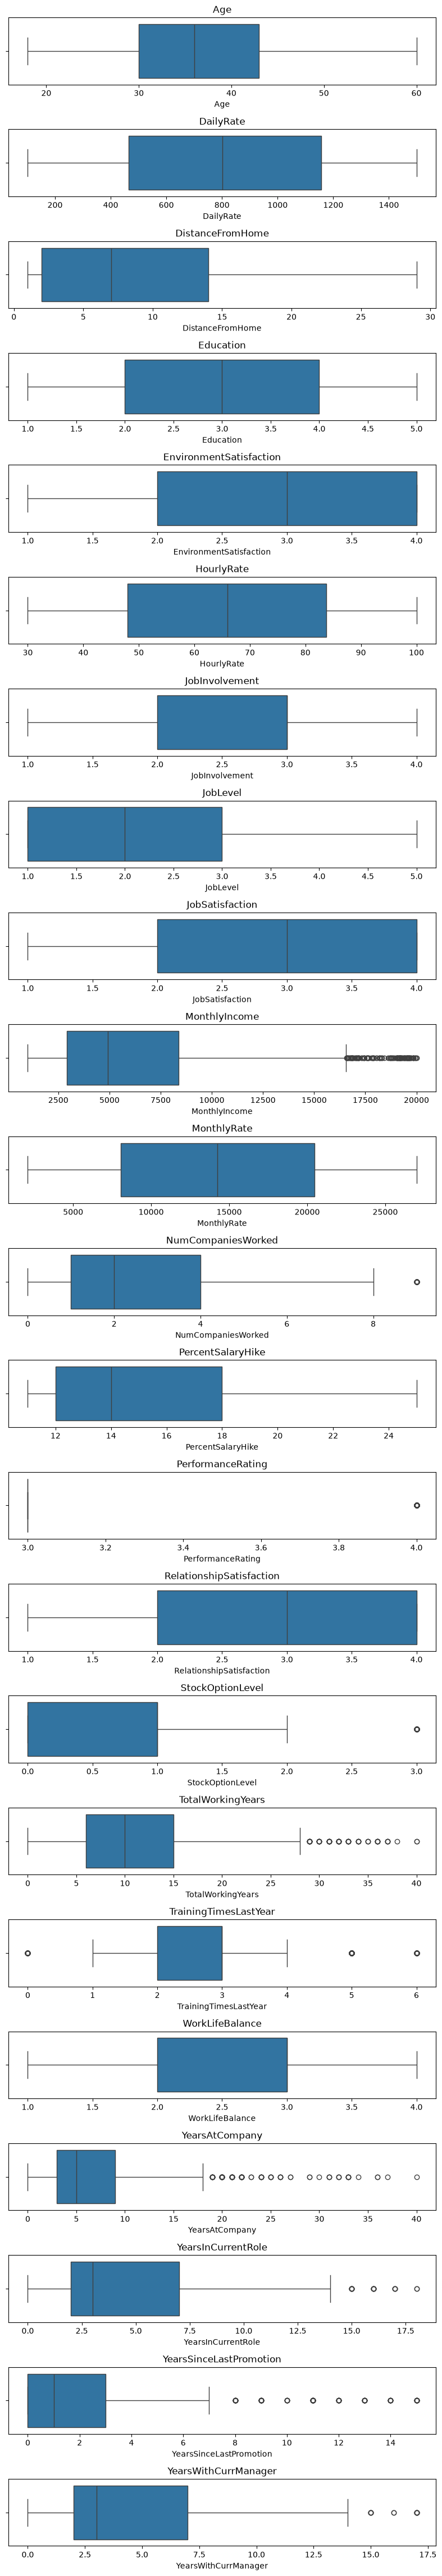

In [18]:
# I check outlire for every numerical columns using box plot
num_cols=df.select_dtypes(include="number").columns   

fig, axs = plt.subplots(
    len(num_cols),
    1,
    figsize=(8, len(num_cols) * 2)
)

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()


## 3. Data Preprocessing

The data was split before fitting preprocessing transformations to reduce the risk of information leakage. The training data was used to fit the encoding and scaling transformations, which were then applied to validation and test data.

The preprocessing workflow includes:

1. Stratified train/validation/test splitting.
2. One-hot encoding of categorical variables.
3. Standardisation of numerical variables using `StandardScaler`.
4. Preservation of the original training data for exploratory analysis.

The target class distribution was retained rather than artificially balanced in this workflow, with class imbalance addressed through the choice of evaluation metrics.

In [19]:
#splitting data into training and testing
X_train, X_rem, y_train, y_rem = train_test_split(X,y,
train_size =0.70, random_state=42,stratify=y)

print("Training set shape: X_train:", X_train.shape, "y_train:", y_train.shape)

Training set shape: X_train: (1029, 30) y_train: (1029,)


In [20]:
# Further splitting the remaining data to test and validation
X_val, X_test, y_val, y_test= train_test_split(X_rem, y_rem, test_size=0.50,random_state=42,stratify=y_rem)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1029, 30)
(220, 30)
(221, 30)


In [21]:
# This keep the original copy of the data before encoding. The copy is kept tob e used during visualization
train_df=X_train.copy()
train_df["Attrition"] = y_train
train_df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
853,19,Travel_Rarely,645,Research & Development,9,2,Life Sciences,3,Male,54,...,3,0,1,4,3,1,1,0,0,No
435,33,Travel_Rarely,1277,Research & Development,15,1,Medical,2,Male,56,...,4,0,15,2,4,7,6,7,7,Yes
587,52,Travel_Rarely,1325,Research & Development,11,4,Life Sciences,4,Female,82,...,2,1,9,3,3,5,2,1,4,No
1170,27,Travel_Frequently,591,Research & Development,2,3,Medical,4,Male,87,...,3,0,6,0,2,4,2,1,2,No
159,34,Travel_Frequently,303,Sales,2,4,Marketing,3,Female,75,...,4,1,6,3,3,4,3,1,2,No


In [22]:
# Separating the columns into categorical variables and numerical variables
categorical_cols = X_train.select_dtypes(include="object").columns
numerical_cols= X_train.select_dtypes(exclude="object").columns
print(categorical_cols)
print(numerical_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str')
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')


C:\Users\hp\AppData\Local\Temp\ipykernel_22292\3150759955.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns


In [23]:
from sklearn.preprocessing import OneHotEncoder

#Identifying categorical columns in order to encode the variables in it.
categorical_cols=X_train.select_dtypes(include="object").columns
print(categorical_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str')


C:\Users\hp\AppData\Local\Temp\ipykernel_22292\3986982113.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=X_train.select_dtypes(include="object").columns


In [24]:
# Encoding the categorical variables.This convert the categorical variables to numerical columns
#  The fitting is done only on training data to prevent data leakage
encoder = OneHotEncoder( drop="first", handle_unknown= "ignore", sparse_output=False)
encoder.fit(X_train[categorical_cols])

,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infre

In [25]:
#Transform all the datasets
X_train_encoded = encoder.transform(X_train[categorical_cols])
X_val_encoded = encoder.transform(X_val[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

In [26]:
# Getting the names of the newly created features after encoding
encoded_columns = encoder.get_feature_names_out(categorical_cols)
print(encoded_columns)

['BusinessTravel_Travel_Frequently' 'BusinessTravel_Travel_Rarely'
 'Department_Research & Development' 'Department_Sales'
 'EducationField_Life Sciences' 'EducationField_Marketing'
 'EducationField_Medical' 'EducationField_Other'
 'EducationField_Technical Degree' 'Gender_Male' 'JobRole_Human Resources'
 'JobRole_Laboratory Technician' 'JobRole_Manager'
 'JobRole_Manufacturing Director' 'JobRole_Research Director'
 'JobRole_Research Scientist' 'JobRole_Sales Executive'
 'JobRole_Sales Representative' 'MaritalStatus_Married'
 'MaritalStatus_Single' 'OverTime_Yes']


In [27]:
# Converting the encoded arrays back to dataframe
X_train_encoded = pd.DataFrame(X_train_encoded, columns = encoded_columns, index= X_train.index)
X_val_encoded = pd.DataFrame(X_val_encoded, columns = encoded_columns, index= X_val.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoded_columns, index= X_test.index)

In [28]:
# This is to keep numerical 
numerical_cols= X_train.select_dtypes(exclude = "object").columns

In [29]:
# Combining Numerical and encoded categorical features to make the final dataset.
#  Doing this will ensure that all predictor variables are available in a single dataset and numerical form suitable
# for machine learning algorithms
X_train_final = pd.concat(
    [X_train[numerical_cols], X_train_encoded], 
    axis= 1)

X_val_final = pd.concat([X_val[numerical_cols], X_val_encoded], axis= 1)

X_test_final = pd.concat([X_test[numerical_cols], X_test_encoded], axis= 1)


In [30]:
X_train_final.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
853,19,645,9,2,3,54,3,1,1,2552,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
435,33,1277,15,1,2,56,3,3,3,13610,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
587,52,1325,11,4,4,82,3,2,3,3149,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1170,27,591,2,3,4,87,3,1,4,2580,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
159,34,303,2,4,3,75,3,1,3,2231,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


### 3.1 Encoded Feature Matrix

After one-hot encoding, categorical variables were converted into numerical features so they could be used by the machine-learning algorithms.

### 3.2 Feature Scaling

Numerical variables such as Age, Monthly Income and Total Working Years have different scales. Standardisation places numerical features on a comparable scale and is particularly relevant to optimisation-based models such as Logistic Regression and the Neural Network. The scaler was fitted only on the training data.

In [31]:
#  Applying  standard scaler to bring the data to similar range
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_final[numerical_cols] = scaler. fit_transform( 
    X_train_final[numerical_cols]
)

X_val_final[numerical_cols] = scaler.transform( 
    X_val_final[numerical_cols])

X_test_final[numerical_cols] = scaler.transform(
    X_test_final[numerical_cols]
)

## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was used to understand the distribution of the target, identify patterns in numerical variables, examine relationships between features and attrition, and identify potential data-quality issues.

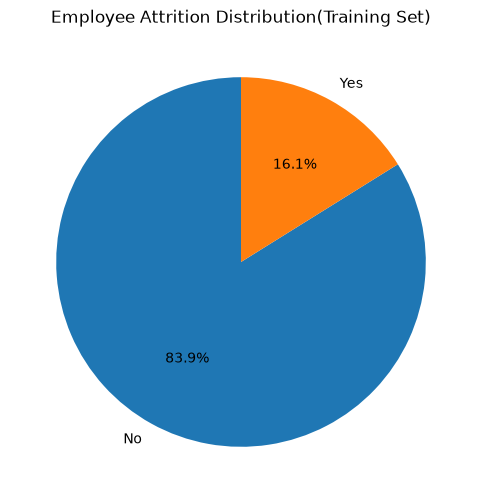

In [32]:
# Using pie chart to show the distribution of Target Variable.
#First we want to check the percentage of attrition and compare it to those that stayed

attrition_counts = y_train.value_counts()

plt.figure(figsize= (6,6))
plt.pie(
    attrition_counts,
    labels= attrition_counts.index,
    autopct ='%1.1f%%',
    startangle=90

)

plt.title("Employee Attrition Distribution(Training Set)")
plt.show()

The target distribution confirms a moderate class imbalance, with approximately 84% of observations representing employees who stayed and 16% representing employees who left. This reinforces the need to evaluate models using more than accuracy alone.

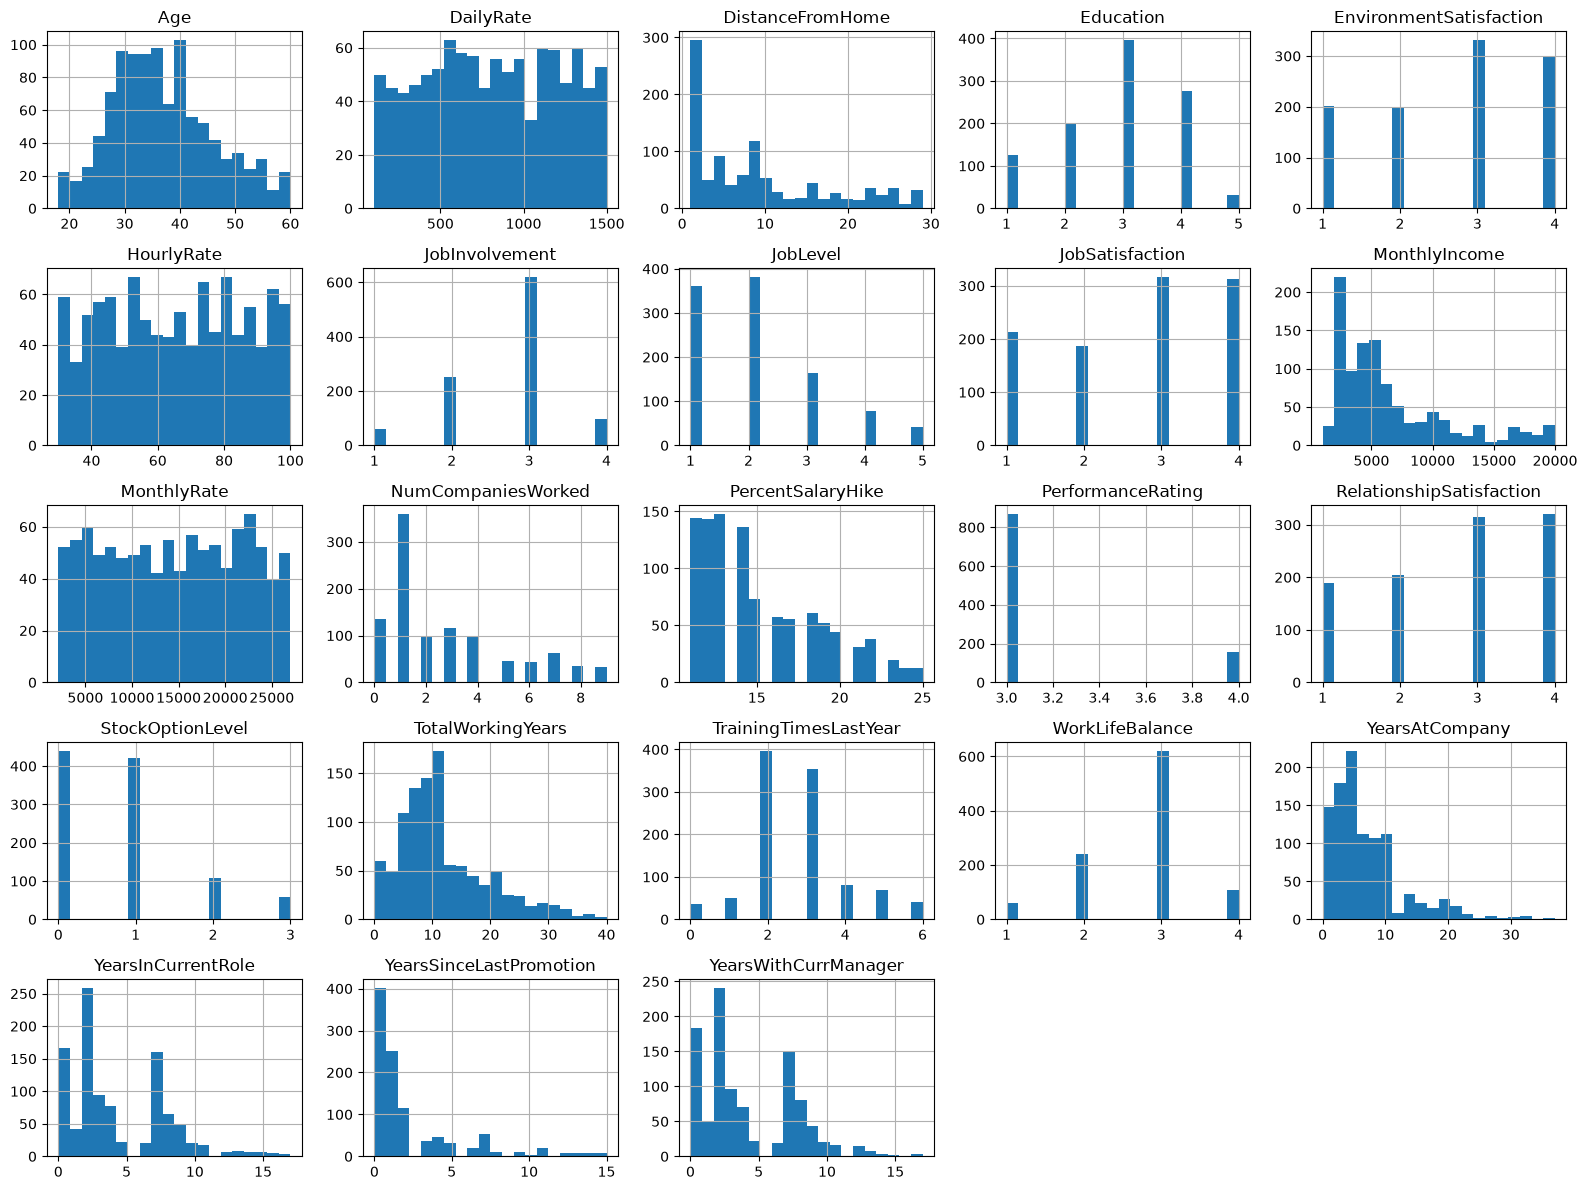

In [33]:
#2. Distribution of numerical variables using histogram for all numerical variables.
X_train[numerical_cols].hist(
    figsize=(16,12), bins=20
)
plt.tight_layout()
plt.show()

The numerical variables show a mixture of distributions. Age is concentrated largely around the 30–40 range, while Monthly Income and several tenure-related variables are positively skewed. These patterns reflect differences in employee seniority, compensation and organisational tenure.

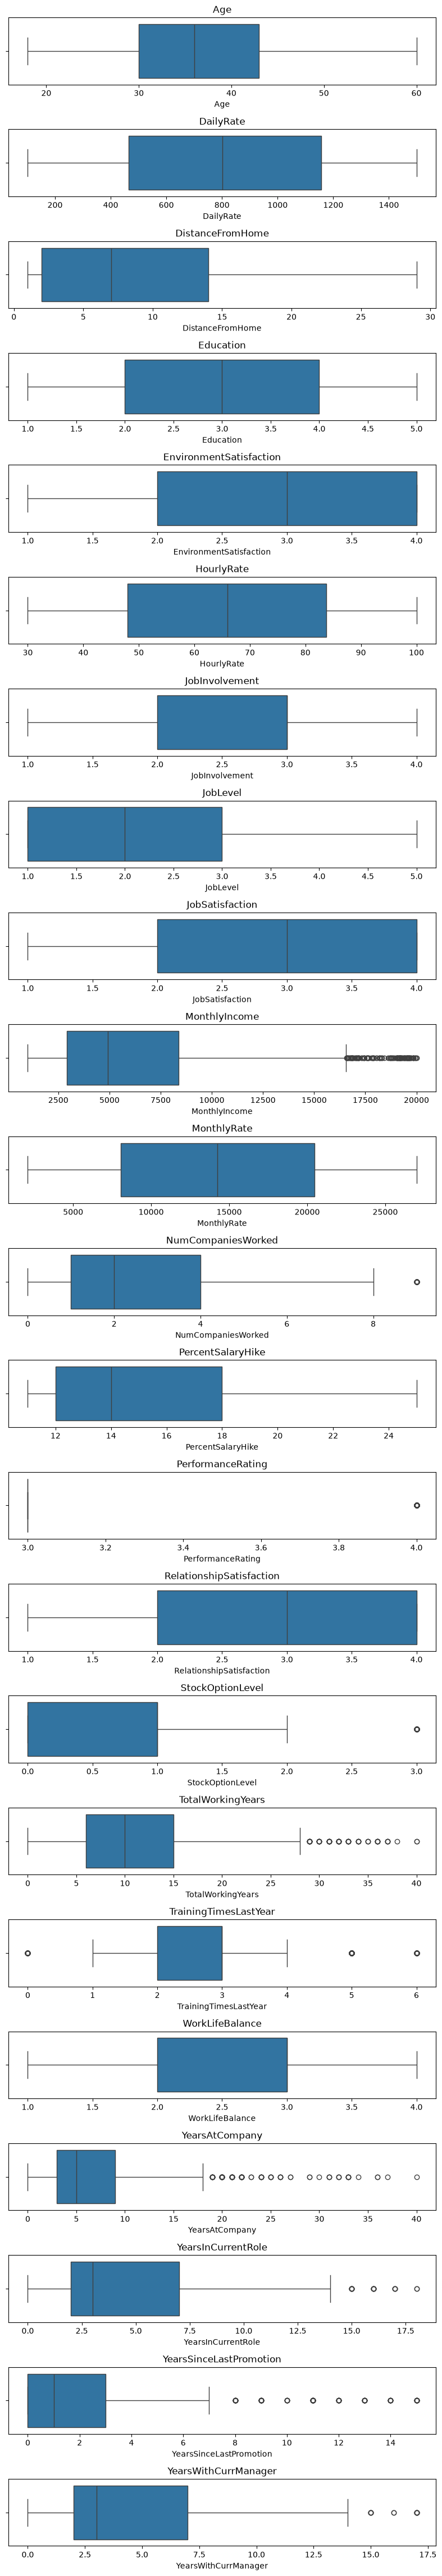

In [34]:
# Identifying and Analysing the outlier
num_cols=df.select_dtypes(include="number").columns   

fig, axs = plt.subplots(
    len(num_cols),
    1,
    figsize=(8, len(num_cols) * 2)
)

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

Several variables, including Monthly Income, Total Working Years, Years At Company and Years With Current Manager, contain observations that appear as outliers. These values were retained because they represent plausible employee characteristics rather than obvious data-entry errors.

<function matplotlib.pyplot.show(close=None, block=None)>

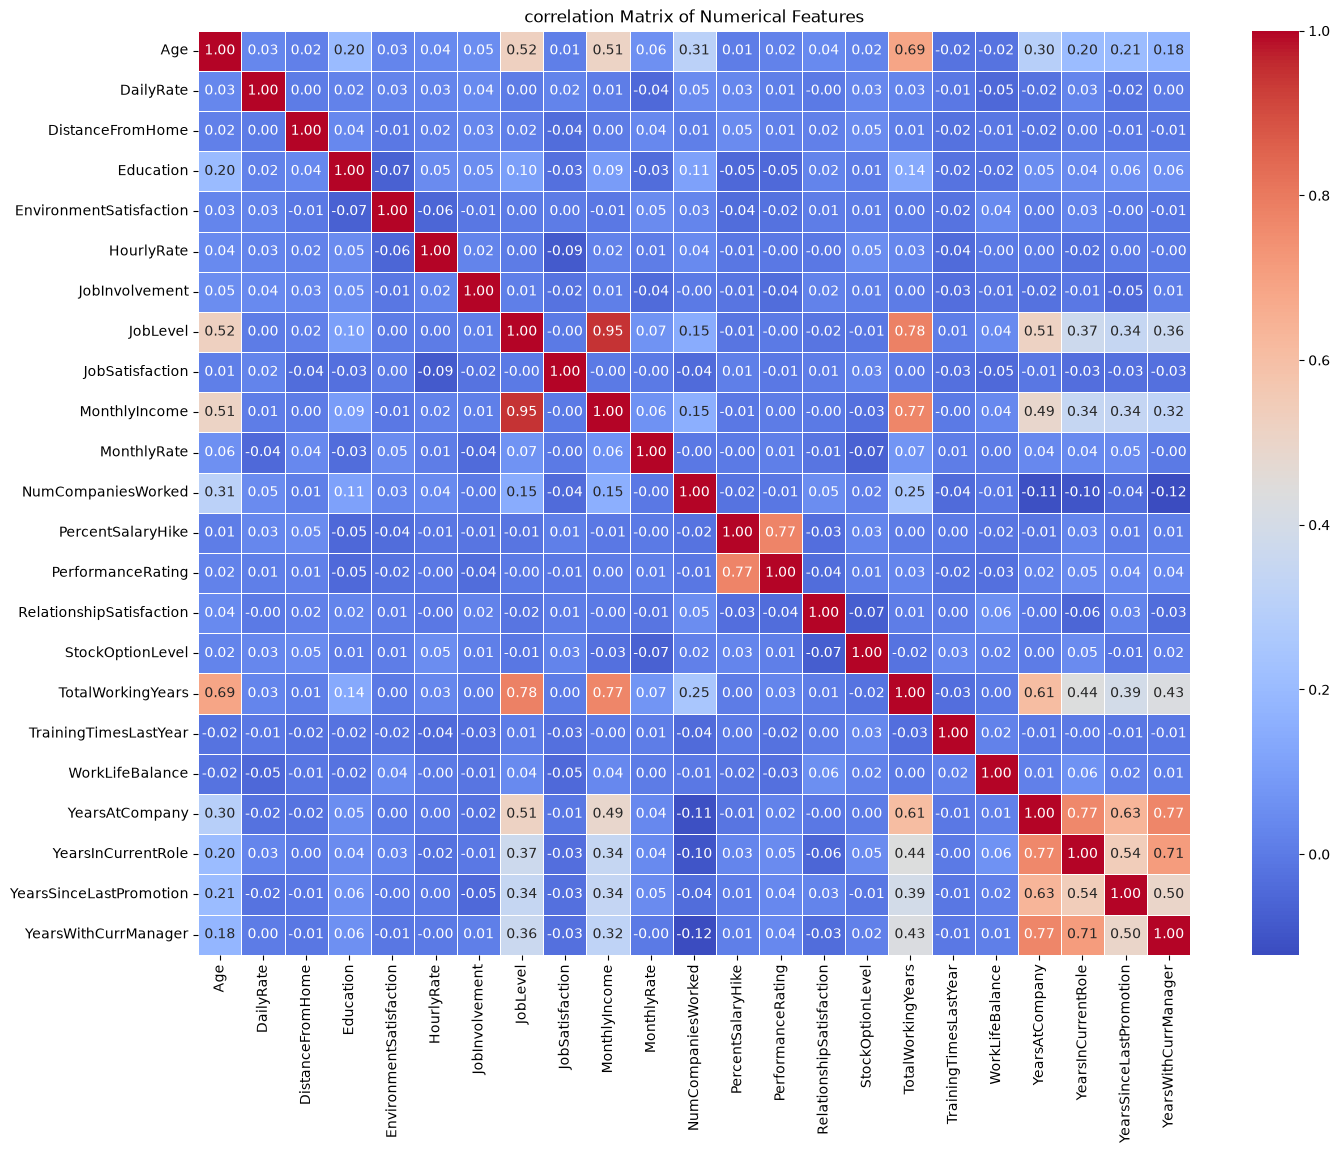

In [35]:
# checking the relationship between the numerical variables and how they relate
# The relationship was observed using heatmap

corr =train_df.select_dtypes(include="number").corr()
plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt= ".2f",
    linewidths=0.5
)

plt.title("correlation Matrix of Numerical Features")
plt.show

The correlation analysis shows several meaningful relationships among employment and compensation variables. For example, Job Level and Monthly Income are strongly positively related, while Age and Total Working Years also show a substantial positive relationship. These relationships are useful for understanding the structure of the workforce and potential redundancy among related predictors.

<function matplotlib.pyplot.show(close=None, block=None)>

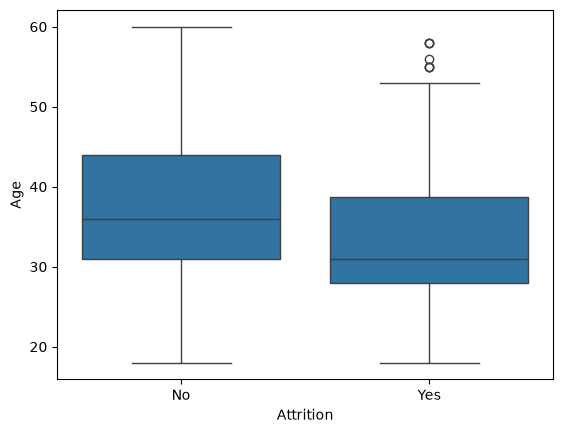

In [36]:
# checking the relationship beween attrition and Age of employees: Do younger employees leave frequently?
sns.boxplot(
    x=train_df["Attrition"],
    y=train_df["Age"]
)

plt.show

The age comparison suggests that younger employees show greater representation among employees who leave than older employees. This is an observed association in the dataset and should not be interpreted as proof that age causes attrition.

<function matplotlib.pyplot.show(close=None, block=None)>

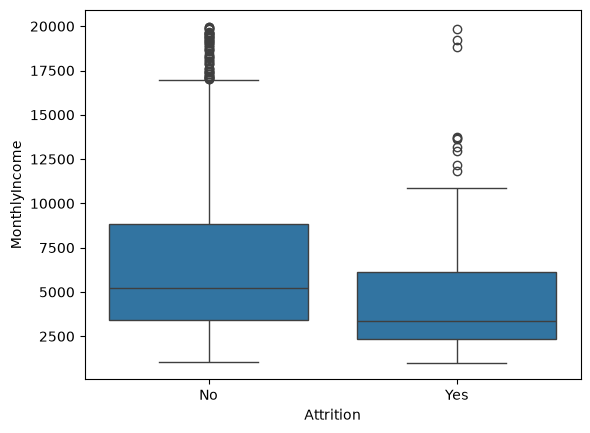

In [37]:
#Does MonthlyIncome affect attrition

sns.boxplot(
    x=train_df["Attrition"],
    y=train_df["MonthlyIncome"]
)

plt.show

Employees with lower Monthly Income appear more frequently among those who leave. This suggests that compensation may be an important factor associated with attrition in this dataset.

<function matplotlib.pyplot.show(close=None, block=None)>

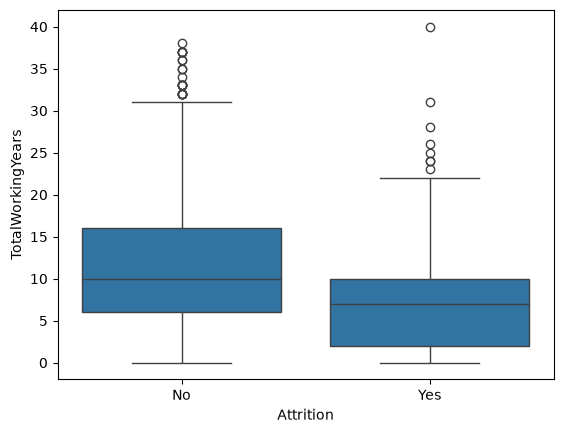

In [38]:
# Attrition and years of working
sns.boxplot(
    x=train_df["Attrition"],
    y=train_df["TotalWorkingYears"]
)

plt.show

Employees with fewer total working years appear more frequently among those who leave, while longer-tenured employees are more concentrated in the group that stays.

<function matplotlib.pyplot.show(close=None, block=None)>

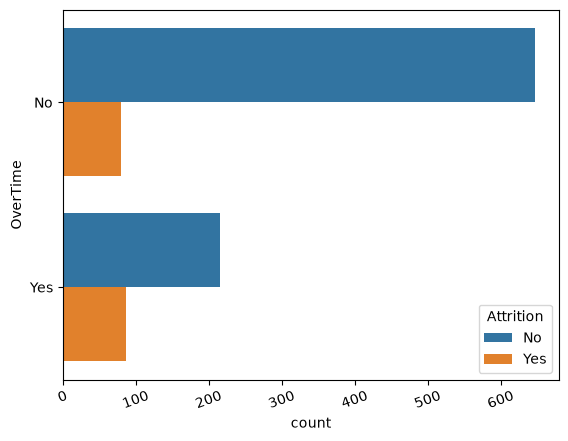

In [39]:
# Attrition and overtime
sns.countplot(
    data=train_df,
    hue="Attrition",
    y="OverTime"
)

plt.xticks(rotation=20)
plt.show

Employees who work overtime show a higher proportion of attrition than employees who do not. Overtime therefore appears to be an important variable to consider when analysing employee retention.

<function matplotlib.pyplot.show(close=None, block=None)>

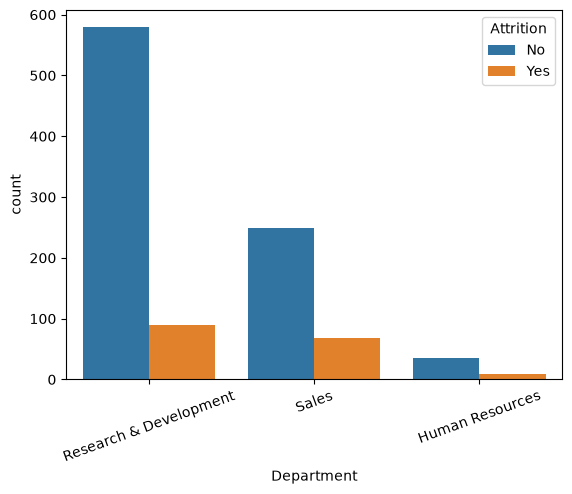

In [40]:
# Attrition and department: This is to check which department has highest attrition
sns.countplot(
    data=train_df,
    hue="Attrition",
    x="Department"
)

plt.xticks(rotation=20)
plt.show

The largest numbers of employees leaving are observed in Research & Development, Sales and Human Resources. Because department sizes differ, these counts should be interpreted alongside department-level attrition rates.

<function matplotlib.pyplot.show(close=None, block=None)>

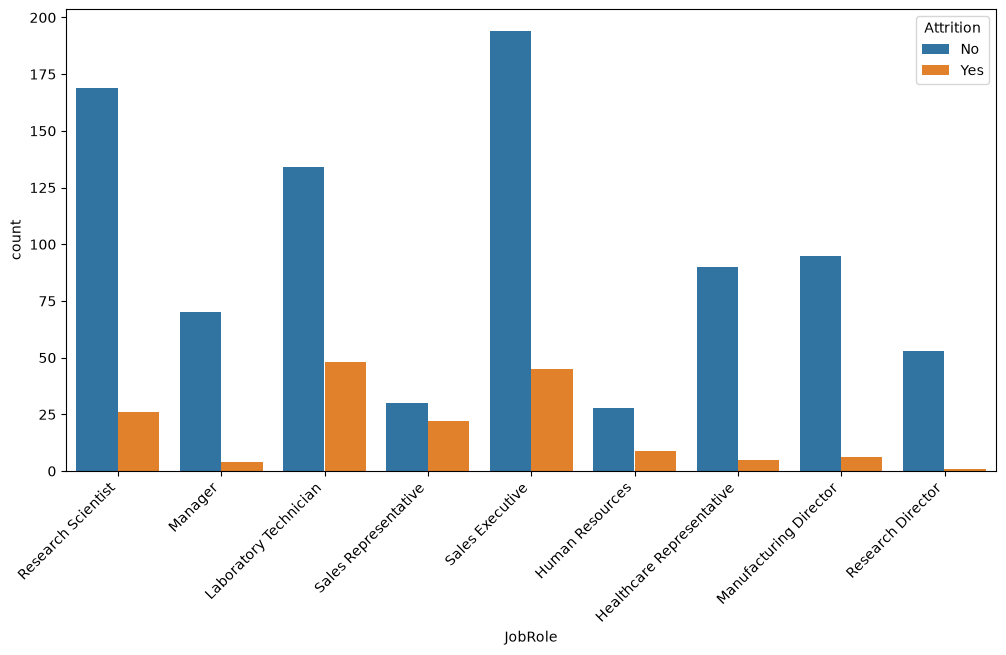

In [41]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=train_df,
    hue="Attrition",
    x="JobRole"
)

plt.xticks(rotation=45, ha="right")
plt.show

The job-role analysis shows Laboratory Technicians, Sales Executives, Research Scientists and Sales Representatives among the roles with notable numbers of employees who left.

## 5. Model Selection Strategy

Employee attrition is a **binary classification problem**. Six algorithms were selected to provide complementary modelling approaches:

- **Logistic Regression** — interpretable linear baseline for binary classification.
- **Decision Tree** — captures non-linear relationships and provides a tree-based decision structure.
- **Random Forest** — ensemble of decision trees designed to improve robustness and predictive performance.
- **Naïve Bayes** — probabilistic baseline based on conditional independence assumptions.
- **Gradient Boosting** — sequential ensemble method that builds trees to correct previous errors.
- **Neural Network** — non-linear model included to assess whether a deep-learning approach improves predictive performance.

The models were evaluated on the held-out test set after training and hyperparameter optimisation.

In [ ]:
#Creating accuracy function
def accuracy(y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    return round(acc*100, 2)

In [94]:
# Reusable ROC-AUC plotting function
def plot_roc_curve(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label="Yes")
    auc_score = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2.5, label=f"{model_name} (AUC = {auc_score:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

In [95]:
# This create model evaluation function
def model_performance(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    ps = precision_score(y_true, y_pred, average='weighted')
    rs = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    performance = {
        'Algorithm': model_name,
        'Accuracy': round(acc*100, 2),
        'Precision': round(ps*100, 2),
        'Recall': round(rs*100, 2),
        'F1 Score': round(f1*100, 2)
    }
    return performance

## 5.1 Logistic Regression

Logistic Regression was used as an interpretable baseline because the target is binary. It estimates the probability of an employee belonging to the attrition class and provides a useful benchmark against more complex algorithms.

In [96]:
# Using Logistic Regression First 
logreg = LogisticRegression(max_iter = 5000, random_state = 42)
logreg.fit(X_train_final, y_train)
y_pred_logreg = logreg.predict(X_test_final)
y_pred_prob = logreg.predict_proba(X_test_final)[:, 1]

In [46]:
print("Accuracy of the model: {}%".format(accuracy(y_test, y_pred_logreg)))

Accuracy of the model: 86.88%


In [47]:
# Hyperparameter Tuning using randomsearch CV
param_dist = {
    'C': [0.1, 1, 10, 100], 
    'solver': ['lbfgs', 'liblinear']
}

random_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=5000, random_state=42), 
    param_distributions=param_dist, 
    n_iter=5, 
    cv=10, 
    scoring= "f1",
    random_state=42, 
    n_jobs=-1
)

In [48]:
random_search.fit(X_train_final, y_train)
best_logreg = random_search.best_estimator_
best_logreg

c:\Users\hp\Desktop\project_jupyter\tf_env\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The 

In [49]:
y_pred_best = best_logreg.predict(X_test_final)
y_best_pred_prob= best_logreg.predict_proba(X_test_final)[:,1]
print("Accuracy of the model: {}%".format(accuracy(y_test, y_pred_best)))

Accuracy of the model: 87.33%


### ROC-AUC Evaluation

ROC curves assess how well a classifier separates employees who left from employees who stayed across different probability thresholds. The AUC summarises this discrimination ability: higher values indicate stronger separation between the two classes.

In [50]:
# The reusable ROC-AUC function defined earlier is used for all classical models.

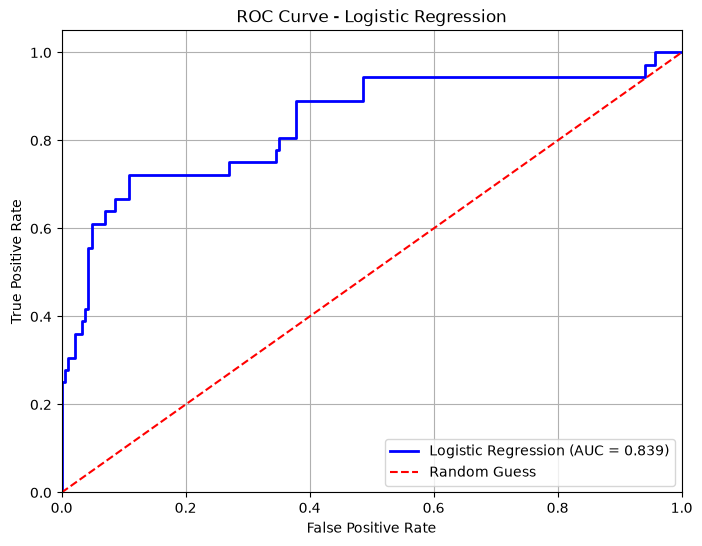

In [51]:
plot_roc_curve(
    y_test,
    y_pred_prob,
    "Logistic Regression"
)

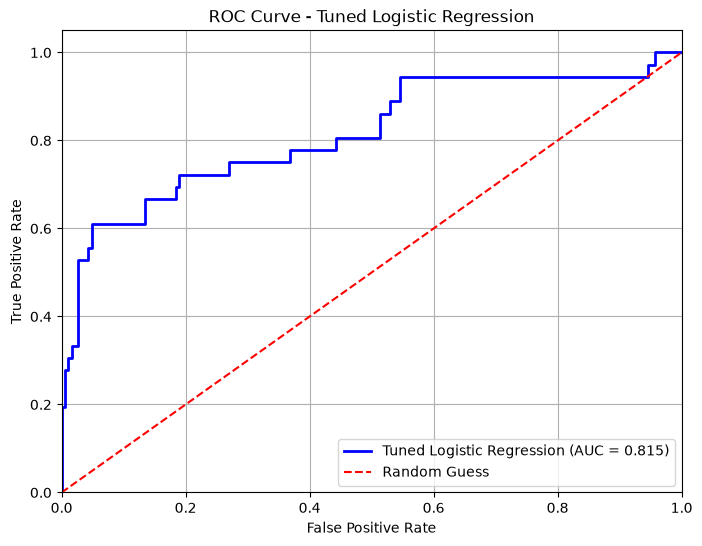

In [ ]:
# This is the ROC Curve after applying hperparameter tuninig
plot_roc_curve(
    y_test,
    y_best_pred_prob,
    "Tuned Logistic Regression"
)

### Effect of Hyperparameter Tuning

The tuned Logistic Regression model was selected using `scoring="f1"`. Therefore, the search optimised F1-score rather than ROC-AUC. The observed reduction in ROC-AUC after tuning is not necessarily evidence that tuning failed; it shows that optimising one evaluation objective does not guarantee improvement in every metric.

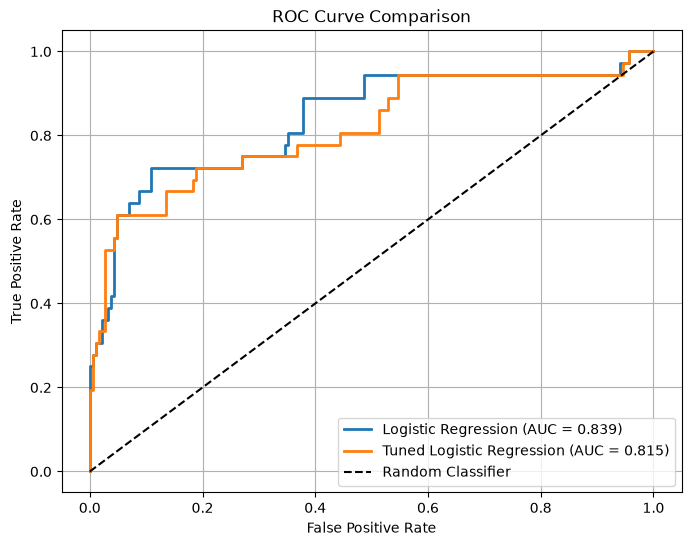

In [54]:
# Comparing logistic regression and the tuned logistic regression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Original Logistic Regression
fpr1, tpr1, _ = roc_curve(y_test, y_pred_prob, pos_label="Yes")
auc1 = roc_auc_score(y_test, y_pred_prob)

# Tuned Logistic Regression
fpr2, tpr2, _ = roc_curve(y_test, y_best_pred_prob, pos_label="Yes")
auc2 = roc_auc_score(y_test, y_best_pred_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr1,
    tpr1,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc1:.3f})"
)

plt.plot(
    fpr2,
    tpr2,
    linewidth=2,
    label=f"Tuned Logistic Regression (AUC = {auc2:.3f})"
)

plt.plot([0,1], [0,1], 'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

The ROC-AUC Curve shows difference between the logistic regression before and after tuning. The AUC before tuning is higher (0.83) than after tuning (0.815). This might be cause by the optimisation using F1 scoring which is necessary considering that the target variable is imbalance.

In [ ]:
#Saving the model performance
lr_performance = model_performance(
    y_true=y_test, 
    y_pred=y_pred_best, 
    model_name='Logistic Regression'
)

## 5.2 Decision Tree

A Decision Tree was evaluated to determine whether non-linear decision rules could improve attrition prediction. Hyperparameters controlling tree depth and the minimum number of observations required for splits and leaves were tuned using cross-validation.

In [56]:
param_dist = {
    'max_depth': [None, 50, 100],
    'min_samples_split': [3, 5],
    'min_samples_leaf': [1, 2, 5]
}

# Initialize RandomizedSearchCV
random_search_dtree = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=10,
    random_state=42,
    n_jobs=-1
)

In [57]:
# Fitting the model to the dataset
random_search_dtree.fit(X_train_final, y_train)
best_dtree = random_search_dtree.best_estimator_
best_dtree

c:\Users\hp\Desktop\project_jupyter\tf_env\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [58]:
# Making prediction
y_pred_best_dtree = best_dtree.predict(X_test_final)
y_pred_best_prob_dtree = best_dtree.predict_proba(X_test_final)[:, 1]
print("Accuracy of the model: {}%".format(accuracy(y_test, y_pred_best_dtree)))

Accuracy of the model: 79.19%


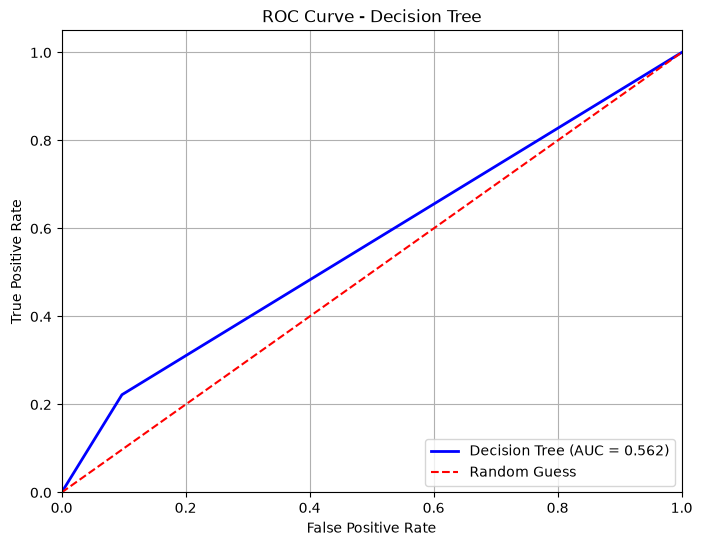

In [59]:
#plotting the ROC curve
plot_roc_curve(
    y_true=y_test,
    y_prob=y_pred_best_prob_dtree,
    model_name="Decision Tree"
)

In [60]:
dt_performance = model_performance(
    y_true=y_test, 
    y_pred=y_pred_best_dtree, 
    model_name='Decision Tree'
)

Random Forest

Random Forest is an ensemble learning technique that combines the predictions of numerous Decision Trees to create a more accurate and robust classification model. Random Forest reduces overfitting by generating numerous trees from randomly selected subsets of the training data and predictor variables.

Random Forest was chosen because it works incredibly well with structured information and can model intricate correlations between employe attributes and attrition. Random Forest not only makes accurate forecasts, but it also delivers feature importance scores, which allow you to identify the characteristics that most lead to employe attrition.
RandomisedSearchCV was used to tune hyperparameters such as the number of trees, tree depth, minimum samples necessary for splitting, and minimum samples required at leaf nodes.

In [61]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=10,
    scoring="f1",      # Since employee attrition is imbalanced
    random_state=42,
    n_jobs=-1
)



In [62]:
# Fitting the model to the dataset
random_search_rf.fit(X_train_final, y_train)

best_rf = random_search_rf.best_estimator_
best_rf

c:\Users\hp\Desktop\project_jupyter\tf_env\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",40
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the ri

In [63]:
y_pred_best_rf = best_rf.predict(X_test_final)
y_pred_best_prob_rf = best_rf.predict_proba(X_test_final)[:, 1]
print("Accuracy of the model: {}%".format(accuracy(y_test, y_pred_best_rf)))

Accuracy of the model: 84.62%


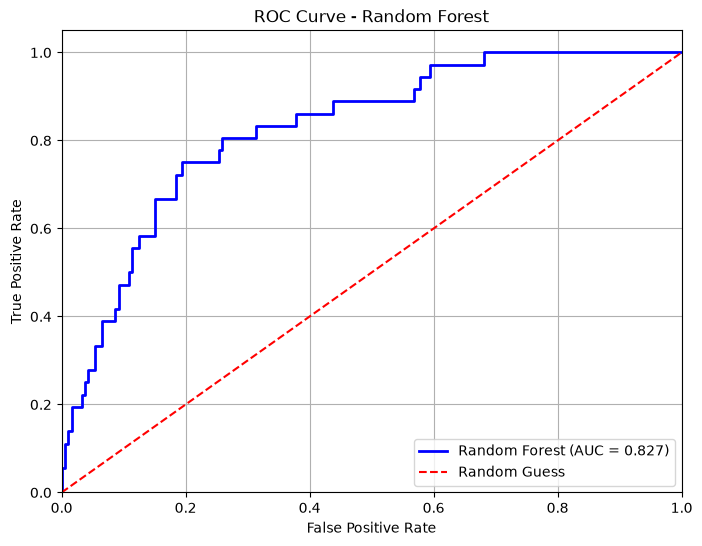

In [64]:
#Plotting the ROC curve
plot_roc_curve(
    y_true=y_test,
    y_prob=y_pred_best_prob_rf,
    model_name="Random Forest"
)

In [65]:
#Saving the random forest performance
rf_performance = model_performance(
    y_true=y_test, 
    y_pred=y_pred_best_rf, 
    model_name='Random Forest'
)

Naive Bayes

Naïve Bayes is a probabilistic classification technique that applies Bayes' Theorem. Given the target class, the method assumes conditional independence of all predictor variables. Despite its limitations in real-world datasets, Naïve Bayes is a reliable baseline classifier.

Random Forest was chosen because it works incredibly well with structured information and can model intricate correlations between employe attributes and attrition. Random Forest not only makes accurate forecasts, but it also delivers feature importance scores, which allow you to identify the characteristics that most lead to employe attrition.

Random Forest reduces overfitting by generating numerous trees from randomly selected subsets of the training data and predictor variables.

This study featured Naïve Bayes, which is computationally efficient, requires minimal training time, and performs well on various classification challenges. Comparing its performance to more complicated algorithms reveals whether simulating interactions between employe factors enhances prediction accuracy.

The dataset's continuous numerical variables led to the selection of the Gaussian Naïve Bayes classifier.



In [66]:
from sklearn.naive_bayes import GaussianNB
param_dist = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

random_search_nb = RandomizedSearchCV(
    estimator=GaussianNB(), 
    param_distributions=param_dist, 
    n_iter=10, 
    scoring= "f1",
    cv=10, 
    random_state=42, 
    n_jobs=-1
)

In [67]:
# Fittting the algorithm on the dataset
random_search_nb.fit(X_train_final, y_train)

best_nb = random_search_nb.best_estimator_
best_nb

c:\Users\hp\Desktop\project_jupyter\tf_env\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",np.float64(2....868435799e-08)
,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[863.,166.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.84,0.16]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[<U3](2,)","['No','Yes']"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,2.848e-08
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](44,)","['Age','DailyRate','DistanceFromHome',...,'MaritalStatus_Married', 'MaritalStatus_Single','OverTime_Yes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,44
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 44)","[[ 0.08, 0.03,-0.03,..., 0.49, 0.28, 0.25], [-0.42,-0.14, 0.18,..., 0.34, 0.51, 0.52]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 44)","[[0.95,0.99,0.98,...,0.25,0.2 ,0.19], [1.05,1.04,1.08,...,0.23,0.25,0.25]]"


In [68]:
y_pred_best_nb = best_nb.predict(X_test_final)
y_pred_best_prob_nb = best_nb.predict_proba(X_test_final)[:, 1]
print("Accuracy of the model: {}%".format(accuracy(y_test, y_pred_best_nb)))

Accuracy of the model: 66.06%


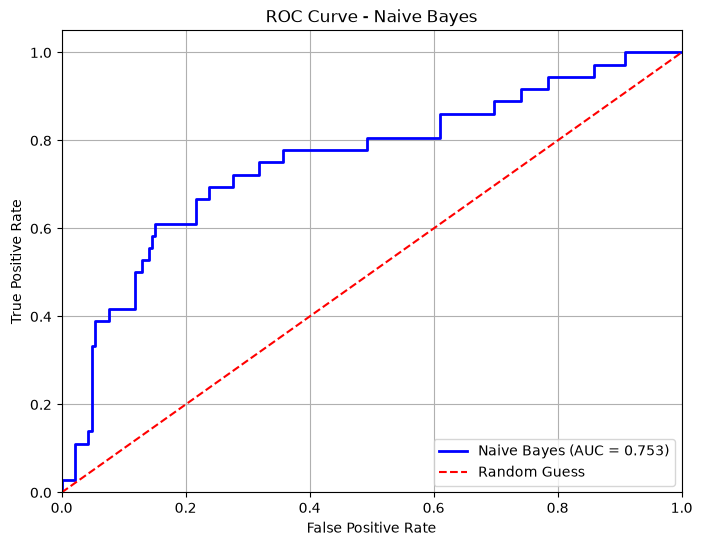

In [69]:
# Plotting Native Bayes ROC Curve
plot_roc_curve(
    y_true=y_test,
    y_prob=y_pred_best_prob_nb,
    model_name="Naive Bayes"
)

In [70]:
nb_performance = model_performance(
    y_true=y_test, 
    y_pred=y_pred_best_nb, 
    model_name='Naive Bayes'
)

## 5.5 Gradient Boosting

In [71]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features': ['auto', 'sqrt', 'log2', None]
}

random_search_gb = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    scoring="f1",
    cv=10,
    random_state=42,
    n_jobs=-1
)

In [72]:
# Fitting the model
random_search_gb.fit(X_train_final, y_train)
best_gb = random_search_gb.best_estimator_

c:\Users\hp\Desktop\project_jupyter\tf_env\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


In [73]:
y_pred_best_gb = best_gb.predict(X_test_final)
y_pred_best_prob_gb = best_gb.predict_proba(X_test_final)[:, 1]
print("Accuracy of the model: {}%".format(accuracy(y_test, y_pred_best_gb)))

Accuracy of the model: 85.07%


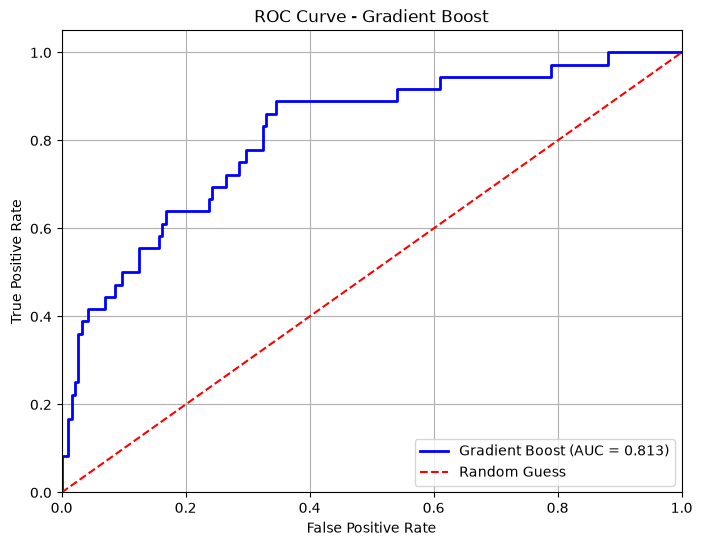

In [74]:
# Plotting Gradient Boost ROC Curve
plot_roc_curve(
    y_true=y_test,
    y_prob=y_pred_best_prob_gb,
    model_name="Gradient Boost"
)

In [75]:
gb_performance = model_performance(
    y_true=y_test, 
    y_pred=y_pred_best_gb, 
    model_name='Gradient Boosting'
)

## 6. Feature Importance

Random Forest feature importance was used to identify which encoded predictors contributed most to the model's predictions. Feature importance indicates predictive contribution within this model; it does not establish causation.

In [76]:
# This tells how influential a feature is in predicting employee attrition
feature_importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': feature_importances
})
feature_importance_df= feature_importance_df.sort_values(
    by='Importance', ascending=False)

feature_importance_df.head()

,Feature,Importance
9,MonthlyIncome,0.100247
0,Age,0.065476
16,TotalWorkingYears,0.062920
43,OverTime_Yes,0.060613
19,YearsAtCompany,0.049176


The feature-importance results show that **Monthly Income, Age, Total Working Years, OverTime_Yes and Years At Company** are among the strongest predictors in the Random Forest model. These variables provide useful signals for understanding which employee characteristics are most associated with model predictions.

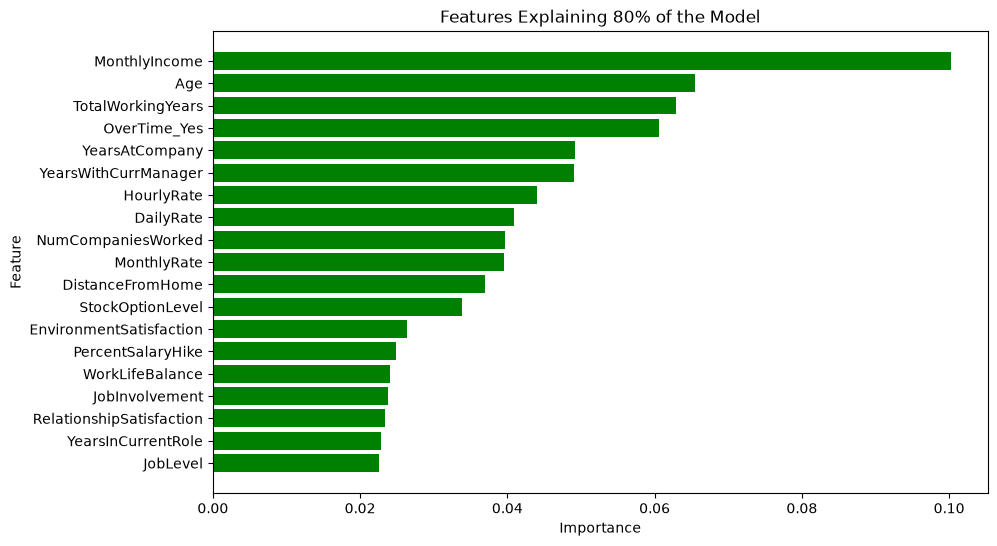

In [77]:
#This check the cummulative feature importance
feature_importance_df['Cumulative Importance'] = feature_importance_df['Importance'].cumsum()
important_features_80 = feature_importance_df[feature_importance_df['Cumulative Importance'] <= 0.80]

# Plot the important features
plt.figure(figsize=(10, 6))
plt.barh(important_features_80['Feature'], important_features_80['Importance'], color='Green')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Features Explaining 80% of the Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.show()

In [78]:
features_of_interest = important_features_80['Feature'].to_list()
X_train_final_top_features = X_train_final[features_of_interest].copy()
X_test_final_top_features = X_test_final[features_of_interest].copy()

In [79]:
print("Number of features in the original dataset:", X_train_final.shape[1])
print("Number of features in the reduced dataset:", X_train_final_top_features.shape[1])

Number of features in the original dataset: 44
Number of features in the reduced dataset: 19


In [83]:
random_search_rf.fit(X_train_final_top_features, y_train)
best_rf_reduced = random_search_rf.best_estimator_
best_rf_reduced

c:\Users\hp\Desktop\project_jupyter\tf_env\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",40
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the ri

In [84]:
y_pred_best_reduced_rf = best_rf_reduced.predict(X_test_final_top_features)
print("Accuracy of the model: {}%".format(accuracy(y_test, y_pred_best_reduced_rf)))

Accuracy of the model: 85.07%


## 7. Neural Network

A feedforward Neural Network was developed to test whether a non-linear deep-learning model could improve employee attrition prediction. The network uses dense layers with ReLU activation, dropout regularisation and a sigmoid output for binary classification. Hyperparameters including dropout rate, batch size and number of epochs were explored using cross-validation.

In [85]:
from sklearn.preprocessing import LabelEncoder
x_nn_train = X_train_final.to_numpy()
x_nn_test = X_test_final.to_numpy()

x_nn_train = np.asarray(x_nn_train).astype('float32')
x_nn_test = np.asarray(x_nn_test).astype('float32')

encoder = LabelEncoder()  # The Y_train was encoded using label encoder
y_nn_train = encoder.fit_transform(y_train)
y_nn_test = encoder.transform(y_test)

In [86]:
x_nn_train.shape

(1029, 44)

In [87]:
y_nn_test.shape

(221,)

In [ ]:
#Creating Neural network 
def create_model(optimizer='adam', dropout_rate=0.0):
    model = Sequential()
    model.add(Input(shape=(x_nn_train.shape[1],)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate))

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout_rate))

    model.add(Dense(16, activation='relu'))

    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = KerasClassifier(
    model=create_model, 
    optimizer='adam',
    dropout_rate=0.3,
    batch_size=32,
    epochs=10
)

param_dist = {
    'optimizer': ['adam'],
    'dropout_rate': [0.3, 0.5, 0.7],
    'batch_size': [32, 64],
    'epochs': [10, 25]
}

random_search_nn = RandomizedSearchCV(
    estimator=model, 
    param_distributions=param_dist, 
    n_iter=5, 
    scoring='f1', 
    cv=3, 
    random_state=42,
    verbose=0
)

random_search_result = random_search_nn.fit(x_nn_train, y_nn_train)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.3236 - loss: 1.1900
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4052 - loss: 0.9149 
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5408 - loss: 0.7632 
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6603 - loss: 0.6528
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7289 - loss: 0.5722 
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7347 - loss: 0.5828 
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7653 - loss: 0.5614
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7799 - loss: 0.5221
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7857 - loss: 0.5392 
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7915 - loss: 0.5332  
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4971 - loss: 0.8666
Epoch 2/10
11/11 ━━━━

In [89]:
best_nn = random_search_result.best_estimator_
random_search_result

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'batch_size': [32, 64], 'dropout_rate': [0.3, 0.5, ...], 'epochs': [10, 25], 'optimizer': ['adam']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the a

In [90]:
y_pred_best_nn = best_nn.predict(x_nn_test)
y_pred_best_prob_nn = best_nn.predict_proba(x_nn_test)[:, 1]
print("Accuracy of the model: {}%".format(accuracy(y_nn_test, y_pred_best_nn)))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy of the model: 84.16%


In [91]:
nn_performance = model_performance(
    y_true=y_nn_test, 
    y_pred=y_pred_best_nn, 
    model_name='Neural Network'
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


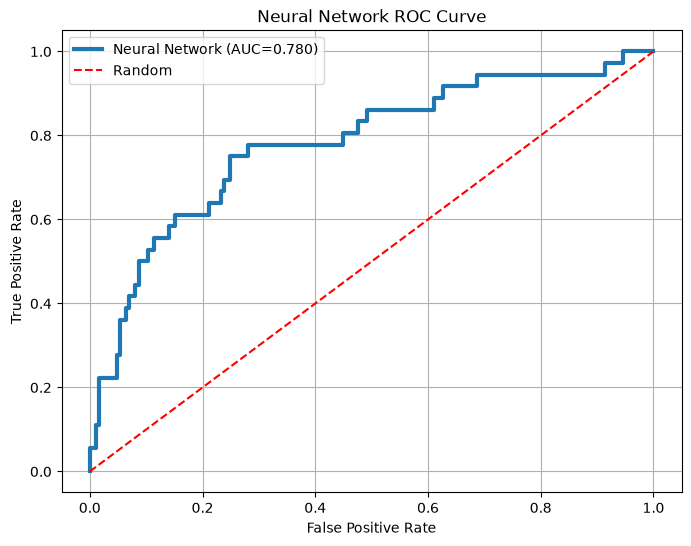

In [93]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Get predicted probabilities from the trained Neural Network
y_nn_prob = best_nn.predict_proba(x_nn_test)[:, 1]

# 2. Calculate AUC
nn_auc = roc_auc_score(y_nn_test, y_nn_prob)

# 3. Calculate ROC curve
fpr_nn, tpr_nn, _ = roc_curve(
    y_nn_test,
    y_nn_prob,
    pos_label=1
)

# 4. Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_nn,
    tpr_nn,
    linewidth=3,
    label=f"Neural Network (AUC={nn_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    'r--',
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Neural Network ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

## 8. Model Evaluation and Comparison

All six classifiers were assessed on the unseen test set using Accuracy, Precision, Recall and F1-score. ROC-AUC was also evaluated separately because the target is imbalanced and discrimination across probability thresholds is important.

The comparison considers three practical dimensions: **predictive performance, class discrimination and interpretability**.

### ROC-AUC Comparison

| Algorithm | ROC-AUC |
|---|---:|
| Random Forest | **0.827** |
| Logistic Regression | 0.815 |
| Gradient Boosting | 0.813 |
| Neural Network | 0.780 |
| Naïve Bayes | 0.753 |
| Decision Tree | 0.562 |

Random Forest achieved the highest ROC-AUC, while Logistic Regression provided the strongest overall balance of the classification metrics reported in the project.

In [ ]:
performance_list = [
    lr_performance,
    nb_performance,
    dt_performance,
    rf_performance,
    gb_performance,
    nn_performance
]

performance_df = pd.DataFrame(performance_list)
performance_df_sorted = performance_df.sort_values(by='Accuracy', ascending=False)
performance_df_sorted

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,87.33,85.99,87.33,85.51
5,Neural Network,87.33,86.13,87.33,85.22
4,Gradient Boosting,85.07,82.72,85.07,81.10
3,Random Forest,84.62,81.60,84.62,81.24
2,Decision Tree,79.19,76.70,79.19,77.78
1,Naive Bayes,66.06,82.55,66.06,70.47


## 9. Model Evaluation Summary

Six machine-learning algorithms were evaluated for employee attrition prediction. Logistic Regression and the Neural Network achieved the highest accuracy at **87.33%**. Logistic Regression produced the highest F1-score at **85.51%**, slightly above the Neural Network's **85.22%**.

Random Forest achieved the highest ROC-AUC (**0.827**), followed by Logistic Regression (**0.815**) and Gradient Boosting (**0.813**). The Neural Network achieved **0.780**, Naïve Bayes **0.753**, and Decision Tree **0.562**.

Overall, Logistic Regression was selected as the preferred model because it offered the strongest balance of accuracy, precision, recall and F1-score while remaining relatively simple to interpret. Random Forest remains important from a discrimination perspective because it achieved the highest ROC-AUC.

## 10. Conclusion

This project developed and evaluated six machine-learning models for employee attrition prediction using the IBM HR Analytics dataset. The workflow covered data-quality checks, preprocessing, exploratory analysis, model training, hyperparameter tuning, performance evaluation and feature-importance analysis.

Logistic Regression provided the strongest overall balance of classification metrics, achieving **87.33% accuracy, 85.99% precision, 87.33% weighted recall and 85.51% weighted F1-score**, with a ROC-AUC of **0.815**. Random Forest produced the highest ROC-AUC at **0.827**, showing strong class-discrimination ability, but its accuracy and F1-score were lower than Logistic Regression.

The feature-importance analysis highlighted Monthly Income, Age, Total Working Years, OverTime_Yes and Years At Company as leading predictors in the Random Forest model. These findings can inform further HR analysis and retention strategies, although model associations should not be interpreted as causal relationships.

### Limitations and Future Work

The dataset is relatively small and moderately imbalanced, and it represents a specific HR dataset rather than a broad cross-section of organisations. Future work could test the approach on larger datasets, explore class-balancing strategies, use stronger ensemble methods such as XGBoost, and apply explainable-AI techniques such as SHAP for more detailed model interpretation.

---

## Portfolio Takeaways

This project demonstrates an end-to-end applied machine-learning workflow: defining a business problem, inspecting and preparing real-world tabular data, exploring patterns, comparing multiple classification algorithms, tuning hyperparameters, evaluating models with appropriate metrics, and interpreting model features.

**Core tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, TensorFlow/Keras.

**Business domain:** Human Resources / People Analytics.

**Key outcome:** Logistic Regression was selected as the preferred model based on its overall balance of predictive performance and interpretability, while Random Forest achieved the strongest ROC-AUC.